In [ ]:
#LSTM Deep Learning & MLflow Serving

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
import sys
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller, acf, pacf

In [ ]:
LOG_FILE = 'lstm_deep_learning.log'
logger = logging.getLogger('lstm_deep_learning')
logger.setLevel(logging.DEBUG)
logger.propagate = False

if not logger.handlers:
    formatter = logging.Formatter(
        '%(asctime)s - %(name)s - %(levelname)s - %(message)s'
    )

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(formatter)

    file_handler = logging.FileHandler(LOG_FILE)
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

logger.info(
    f"Libraries imported and logger configured. "
    f"Full detail is being written to {LOG_FILE}"
)


2026-09-09 06:28:11,129 - lstm_deep_learning - INFO - Libraries imported and logger configured. Full detail is being written to lstm_deep_learning.log


Loading the data

In [ ]:
# Load the dataset
df = pd.read_csv("store_train.csv")

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date")

df = df[df["Open"] == 1].copy()

logger.info(f"Dataset shape after filtering: {df.shape}")

2026-09-09 06:28:15,006 - lstm_deep_learning - INFO - Dataset shape after filtering: (208272, 9)


In [ ]:
# Aggregate sales across all stores for each date
daily_sales = (
    df.groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales = daily_sales.sort_values("Date")

logger.info(f"Daily time series shape: {daily_sales.shape}")
logger.info(
    f"Date range: {daily_sales['Date'].min().date()} "
    f"to {daily_sales['Date'].max().date()}"
)

print(daily_sales.head())

2026-09-09 06:28:28,152 - lstm_deep_learning - INFO - Daily time series shape: (229, 2)
2026-09-09 06:28:28,154 - lstm_deep_learning - INFO - Date range: 2014-12-15 to 2015-07-31
        Date     Sales
0 2014-12-15  12133381
1 2014-12-16  10621060
2 2014-12-17   9483386
3 2014-12-18   9808212
4 2014-12-19   9518489


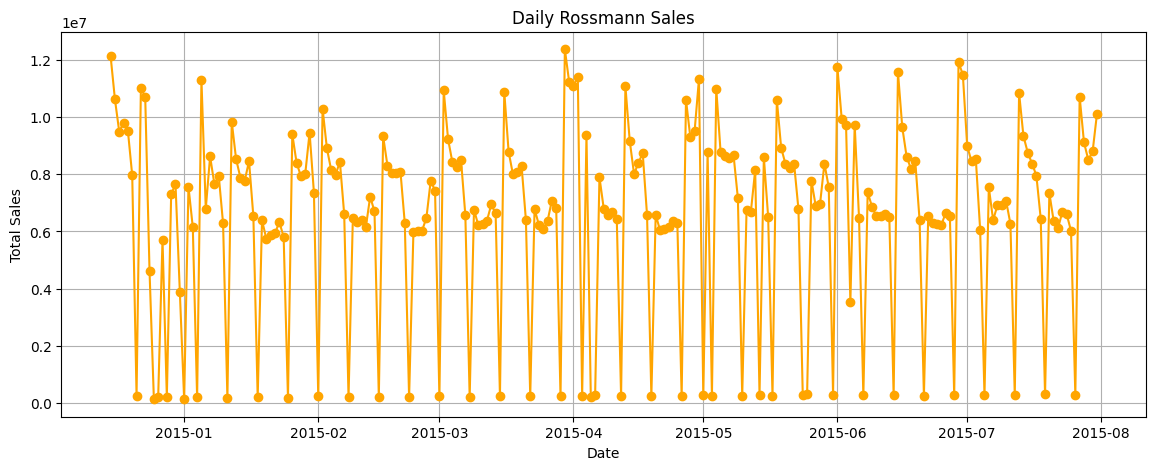

In [ ]:
#Visualising the time series
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    color="orange",
    marker="o",
    linestyle="-"
)

plt.title("Daily Rossmann Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

ADF Test to check whether the time series is stationary

In [ ]:
# Extracting sales values
sales_series = daily_sales["Sales"].astype(float)

# ADF test
adf_result = adfuller(sales_series.dropna())

adf_statistic = adf_result[0]
p_value = adf_result[1]

logger.info(f"ADF Statistic: {adf_statistic:.4f}")
logger.info(f"ADF p-value: {p_value:.4f}")

if p_value < 0.05:
    logger.info("The time series is stationary.")
else:
    logger.info("The time series is non-stationary.")

2026-09-09 06:30:17,479 - lstm_deep_learning - INFO - ADF Statistic: -3.7352
2026-09-09 06:30:17,481 - lstm_deep_learning - INFO - ADF p-value: 0.0036
2026-09-09 06:30:17,483 - lstm_deep_learning - INFO - The time series is stationary.


In [ ]:
# Differencing

if p_value >= 0.05:

    logger.info("Applying first-order differencing.")

    daily_sales["Sales_Diff"] = (
        daily_sales["Sales"].diff()
    )

    daily_sales = daily_sales.dropna().reset_index(drop=True)

    series_for_model = daily_sales["Sales_Diff"]

else:

    logger.info("No differencing required.")

    series_for_model = daily_sales["Sales"]

2026-09-09 06:40:20,992 - lstm_deep_learning - INFO - No differencing required.


In [ ]:
adf_result_diff = adfuller(series_for_model.dropna())

logger.info(
    f"ADF p-value after differencing: {adf_result_diff[1]:.4f}"
)

2026-09-09 06:41:20,368 - lstm_deep_learning - INFO - ADF p-value after differencing: 0.0036


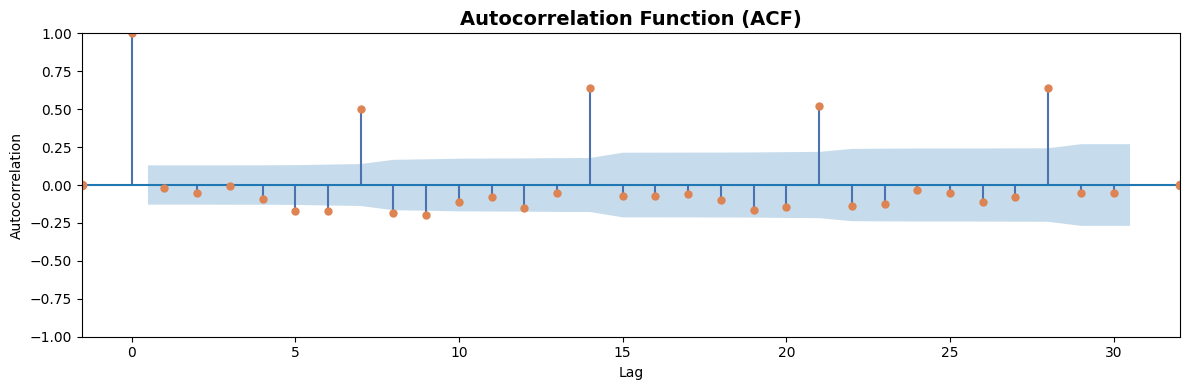

In [ ]:
# ACF Plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(
    series_for_model.dropna(),
    lags=30,
    ax=ax,
    vlines_kwargs={'colors': '#4C72B0', 'linewidth': 1.5},
    marker='o',
    markerfacecolor='#DD8452',
    markeredgecolor='#DD8452'
)

ax.set_title("Autocorrelation Function (ACF)", fontsize=14, fontweight='bold')
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()


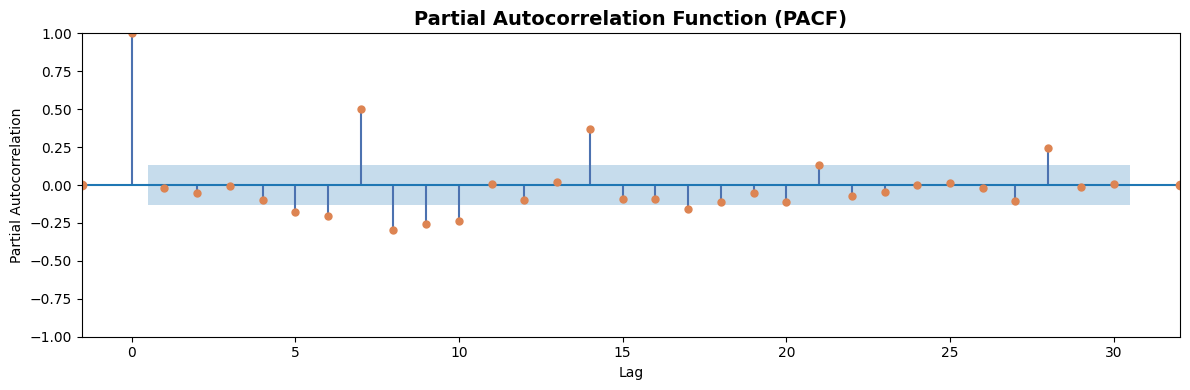

In [ ]:
# PACF Plot
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(12, 4))

plot_pacf(
    series_for_model.dropna(),
    lags=30,
    method="ywm",
    ax=ax,
    vlines_kwargs={'colors': '#4C72B0', 'linewidth': 1.5},
    marker='o',
    markerfacecolor='#DD8452',
    markeredgecolor='#DD8452'
)

ax.set_title(
    "Partial Autocorrelation Function (PACF)",
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()


Transform the time series into supervised learning data

In [ ]:
# Creating Supervised dataset
def create_sequences(data, window_size=30):

    X = []
    y = []

    for i in range(len(data) - window_size):

        X.append(data[i:i + window_size])

        y.append(data[i + window_size])

    return np.array(X), np.array(y)

In [ ]:
# Splitting the time series into train and validation sets
values = series_for_model.values.reshape(-1, 1)

split_index = len(values) - 42

train_values = values[:split_index]
val_values = values[split_index:]

logger.info(f"Training observations: {len(train_values):,}")
logger.info(f"Validation observations: {len(val_values):,}")

2026-09-09 06:52:39,323 - lstm_deep_learning - INFO - Training observations: 187
2026-09-09 06:52:39,328 - lstm_deep_learning - INFO - Validation observations: 42


Scale the data to (-1, 1)

In [ ]:
# Scaling

scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_values)
val_scaled = scaler.transform(val_values)

Create LSTM sequences

In [ ]:
window_size = 30

X_train, y_train = create_sequences(
    train_scaled,
    window_size
)

X_val, y_val = create_sequences(
    val_scaled,
    window_size
)

In [ ]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_val = X_val.reshape(
    X_val.shape[0],
    X_val.shape[1],
    1
)

logger.info(f"X_train shape: {X_train.shape}")
logger.info(f"y_train shape: {y_train.shape}")
logger.info(f"X_val shape: {X_val.shape}")
logger.info(f"y_val shape: {y_val.shape}")

2026-09-09 06:54:11,395 - lstm_deep_learning - INFO - X_train shape: (157, 30, 1)
2026-09-09 06:54:11,397 - lstm_deep_learning - INFO - y_train shape: (157, 1)
2026-09-09 06:54:11,400 - lstm_deep_learning - INFO - X_val shape: (12, 30, 1)
2026-09-09 06:54:11,401 - lstm_deep_learning - INFO - y_val shape: (12, 1)


Build the two-layer LSTM model

In [ ]:
# --------------------------------------------------
# Two-layer LSTM Regression Model
# --------------------------------------------------

tf.random.set_seed(42)

model = Sequential([

    # First LSTM layer
    LSTM(
        64,
        return_sequences=True,
        input_shape=(window_size, 1)
    ),

    Dropout(0.2),

    # Second LSTM layer
    LSTM(32),

    Dropout(0.2),

    # Regression output
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step - loss: 0.2447 - mae: 0.3630 - val_loss: 0.1681 - val_mae: 0.2883
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.2405 - mae: 0.3631 - val_loss: 0.1706 - val_mae: 0.2963
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - loss: 0.2399 - mae: 0.3659 - val_loss: 0.1693 - val_mae: 0.2910
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 665ms/step - loss: 0.2404 - mae: 0.3614 - val_loss: 0.1689 - val_mae: 0.2884
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - loss: 0.2385 - mae: 0.3572 - val_loss: 0.1712 - val_mae: 0.2955
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - loss: 0.2371 - mae: 0.3610 - val_loss: 0.1735 - val_mae: 0.3028
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.2378 - mae: 0.3622 - val_loss: 0.1723 - val_mae: 0.3004
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - loss: 0.2380 - mae: 0.3567 - val_loss: 0.1716 - val_mae: 0.2978
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - loss: 0.2379 - mae: 

Plot training and validation loss

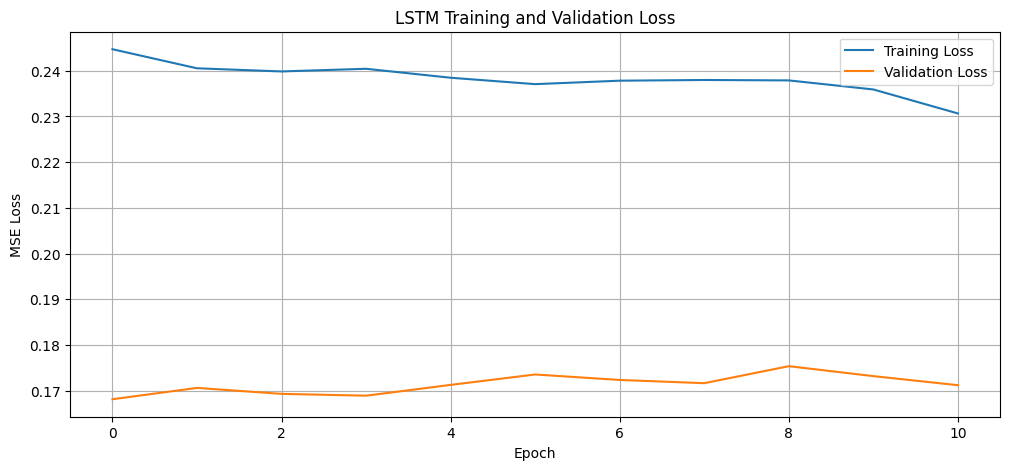

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

Predict the next sales values

In [ ]:
y_pred_scaled = model.predict(X_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
# Inverse transform predictions
y_pred = scaler.inverse_transform(
    y_pred_scaled
)

y_actual = scaler.inverse_transform(
    y_val
)

Evaluate the LSTM model

In [ ]:
rmse = np.sqrt(
    mean_squared_error(y_actual, y_pred)
)

mae = mean_absolute_error(
    y_actual,
    y_pred
)

r2 = r2_score(
    y_actual,
    y_pred
)

logger.info(f"LSTM Validation R2: {r2:.4f}")
logger.info(f"LSTM Validation RMSE: {rmse:,.2f}")
logger.info(f"LSTM Validation MAE: {mae:,.2f}")

2026-09-09 06:57:14,985 - lstm_deep_learning - INFO - LSTM Validation R2: 0.0602
2026-09-09 06:57:14,988 - lstm_deep_learning - INFO - LSTM Validation RMSE: 2,509,442.66
2026-09-09 06:57:14,992 - lstm_deep_learning - INFO - LSTM Validation MAE: 1,764,858.75


Plot actual vs predicted sales

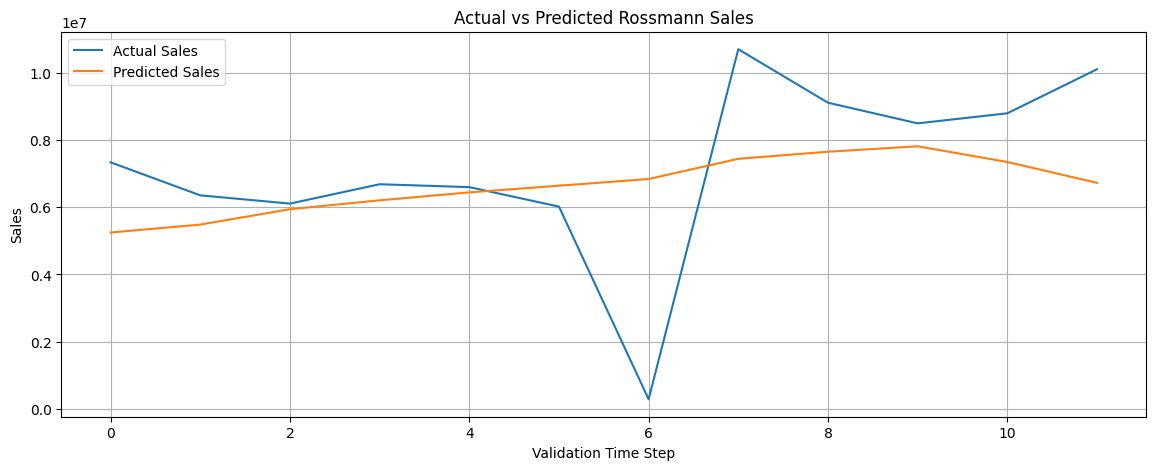

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    y_actual,
    label="Actual Sales"
)

plt.plot(
    y_pred,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Rossmann Sales")
plt.xlabel("Validation Time Step")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#comparison table
comparison_df = pd.DataFrame({
    "Actual Sales": y_actual.flatten(),
    "Predicted Sales": y_pred.flatten()
})

print(comparison_df.head(10))

   Actual Sales  Predicted Sales
0     7339321.0        5249422.5
1     6356482.0        5485790.0
2     6110388.0        5943021.0
3     6687068.0        6208443.0
4     6601325.0        6445003.0
5     6021666.0        6643168.5
6      285865.0        6842885.5
7    10707292.0        7443864.0
8     9115073.0        7655006.0
9     8499962.0        7816621.5
